In [313]:
import numpy as np
import matplotlib.pyplot as plt

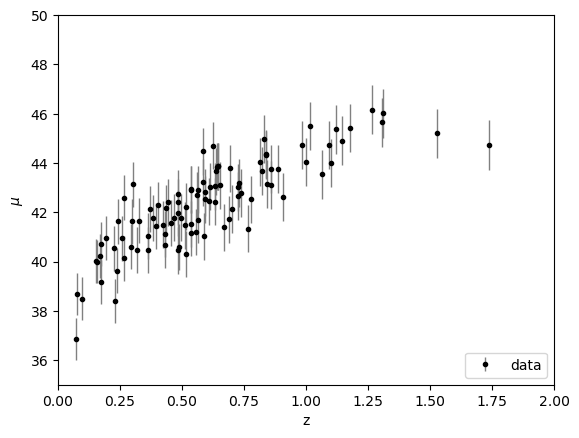

In [314]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [315]:
x_sample = np.reshape(z_sample, [100, 1])
y_sample = mu_sample
x = np.reshape(np.linspace(0, 2, 100), [100, 1])        #how many gaussians
y_err = dmu

In [316]:
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
        
kernel1 = 1.0 * RBF(1.0)
gp = GaussianProcessRegressor(kernel=kernel1, alpha=y_err**2)
gp.fit(x_sample, y_sample)
y_fit, y_std= gp.predict(x, return_std=True)

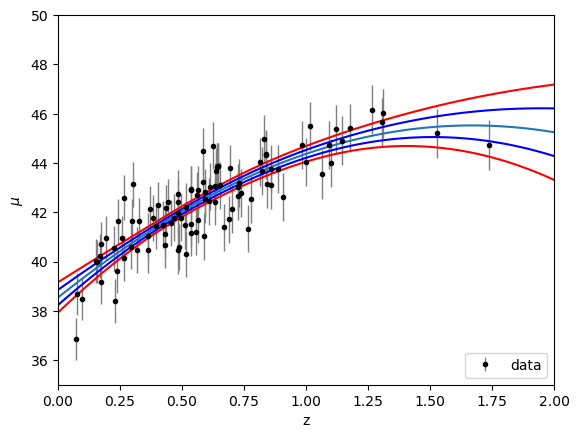

In [317]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')

plt.plot(x, y_fit)
plt.plot(x, y_fit + y_std, c="blue")
plt.plot(x, y_fit - y_std, c="blue")
plt.plot(x, y_fit + 2*y_std, c="red")
plt.plot(x, y_fit - 2*y_std, c="red")

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [318]:
from sklearn.model_selection import GridSearchCV            #from W14
from sklearn.neighbors import KernelDensity

bwrange = np.linspace(0.01, 1.0, 40)
#print(bwrange)
K = 5
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K)
grid.fit(x_sample)
h_opt = grid.best_params_['bandwidth']
print(h_opt)

0.13692307692307693


Text(0.5, 1.0, 'pdf')

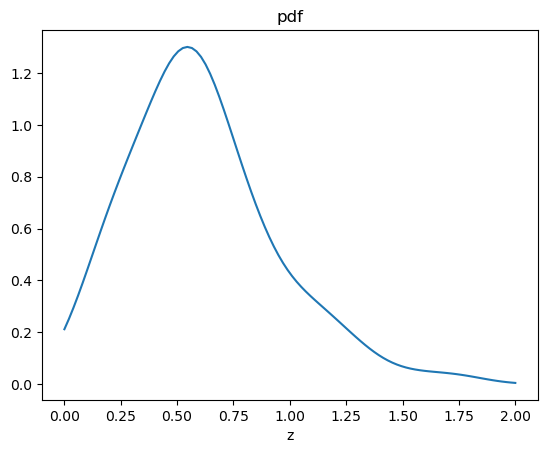

In [319]:
kde_skl = KernelDensity(bandwidth = h_opt)
kde_skl.fit(x_sample)
pdf = np.exp(kde_skl.score_samples(x))

plt.plot(x, pdf)
plt.xlabel("z")
plt.title("pdf")

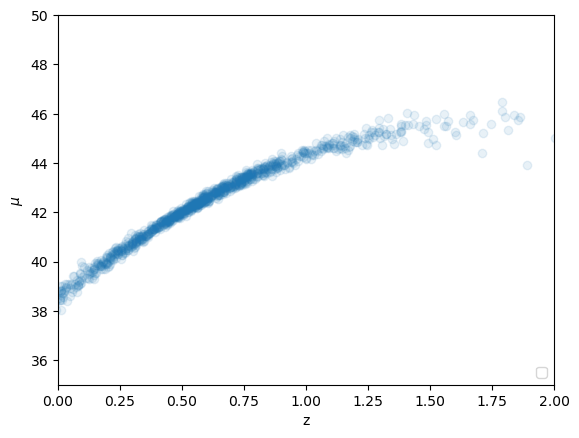

In [320]:
N = 1000
x_sample_generated = kde_skl.sample(N)        #x sample sampled from the pdf of my GPR fit

y_gpr=[]
for z in x_sample_generated.flatten():    
    y_fit, y_std = gp.predict([[z]], return_std=True)
    y_gpr.append(np.random.normal(y_fit, y_std))

plt.scatter(x_sample_generated, y_gpr, alpha=0.1)
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);


In [321]:
from scipy.integrate import quad

def distance_modulus(params, z):
    H0, OM = params
    ODE = 1 - OM        #assume only 2 contributions
    pc = 1e-6           #in megaparsec
    c = 3e5             #km/s
  
    return [5*np.log10((c/H0)/(10*pc)*(1+X)*quad(lambda x: 1/(OM*(1+x)**3 + ODE)**0.5, 0, X)[0]) for X in z]
       

#non è 1+z^3 ma (1+z)^3

In [322]:
#REMEMBER
#plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
#x_sample = np.reshape(z_sample, [100, 1])      is the z
#y_sample = mu_sample                           is the distance modulus
#y_err = dmu                                    is the distance modulus error                                            

data = np.stack((z_sample, y_sample, y_err), axis=1)

#from W11
def Likelihood(params, data, mod=distance_modulus):
    x, y, y_std = np.transpose(data)
    y_model = mod(params, x)
    if params[1]<0: return 0
    return np.prod(np.exp(-(y-y_model)**2 /2 /y_std**2))

def Prior(params):
    H0, OM = params
    if 50 < H0 < 100 and 0.1 < OM < 1:
        return 1.0/10
    return 0


def myPosterior(params, data, mod=distance_modulus):
    return Likelihood(params, data, mod) * Prior(params)

# emcee wants ln of posterior pdf
def myLogPosterior(params, data, mod=distance_modulus):
    a = np.log(myPosterior(params, data, mod))
    if np.isnan(a): return -np.inf
    return a

In [323]:
import emcee
import corner

ndim = 2
nwalkers = 5                #12 minutes not finished with 20 walkers, I'll try 5 like the solution says (instead of 20 from W11)
                            #I also changed the model to use list comprehension instead of append
nsteps = int(1e4)

starting_guesses = starting_guesses = np.array([0.5,80]) + 1e-1* np.random.randn(nwalkers, ndim)


In [324]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, myLogPosterior, args=[data, distance_modulus])
sampler.run_mcmc(starting_guesses, nsteps);
#10 minutes

C:\Users\albad\AppData\Local\Temp\ipykernel_8136\2128976752.py:28: RuntimeWarning: divide by zero encountered in log
  a = np.log(myPosterior(params, data, mod))
c:\Users\albad\.conda\envs\astr\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]


emcee: Exception while calling your likelihood function:
  params: [ 0.479829   80.06232492]
  args: [array([[ 0.29907871, 41.6361725 ,  0.91862497],
       [ 0.64057897, 43.85304855,  0.95818624],
       [ 0.48439381, 42.425679  ,  0.94340343],
       [ 0.83200371, 44.96472492,  0.97222794],
       [ 0.82408678, 43.66317337,  0.97171179],
       [ 0.36113938, 41.0385854 ,  0.92819662],
       [ 0.36402348, 40.47572333,  0.92860378],
       [ 0.8573685 , 43.12308097,  0.97385018],
       [ 1.30588524, 45.64726282,  0.9966678 ],
       [ 0.99995019, 44.02852206,  0.98218018],
       [ 0.42423046, 41.50167538,  0.93649091],
       [ 0.53429221, 42.92901192,  0.948558  ],
       [ 0.70331746, 42.12960007,  0.96318467],
       [ 0.73642792, 42.78840966,  0.9656542 ],
       [ 0.43346403, 42.15345413,  0.93760835],
       [ 0.58487846, 43.20734785,  0.95334492],
       [ 0.5359888 , 42.91403402,  0.94872528],
       [ 0.09800896, 38.48935111,  0.86485225],
       [ 0.81381534, 44.02200845, 

Traceback (most recent call last):
  File "c:\Users\albad\.conda\envs\astr\lib\site-packages\emcee\ensemble.py", line 624, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "C:\Users\albad\AppData\Local\Temp\ipykernel_8136\2128976752.py", line 28, in myLogPosterior
    a = np.log(myPosterior(params, data, mod))
  File "C:\Users\albad\AppData\Local\Temp\ipykernel_8136\2128976752.py", line 24, in myPosterior
    return Likelihood(params, data, mod) * Prior(params)
  File "C:\Users\albad\AppData\Local\Temp\ipykernel_8136\2128976752.py", line 12, in Likelihood
    y_model = mod(params, x)
  File "C:\Users\albad\AppData\Local\Temp\ipykernel_8136\2544825007.py", line 9, in distance_modulus
    return [5*np.log10((c/H0)/(10*pc)*(1+X)*quad(lambda x: 1/(OM*(1+x)**3 + ODE)**0.5, 0, X)[0]) for X in z]
  File "C:\Users\albad\AppData\Local\Temp\ipykernel_8136\2544825007.py", line 9, in <listcomp>
    return [5*np.log10((c/H0)/(10*pc)*(1+X)*quad(lambda x: 1/(OM*(1+x)**3 + ODE)**0.5,

KeyboardInterrupt: 

In [ ]:
samples = sampler.get_chain()
samples.shape

(10000, 5, 2)

In [ ]:
tau = sampler.get_autocorr_time()
print(tau)

In [ ]:
flat_samples = sampler.get_chain(discard=3*int(max(tau)), thin=int(max(tau)), flat=True)
print(flat_samples.shape)

(49985, 2)


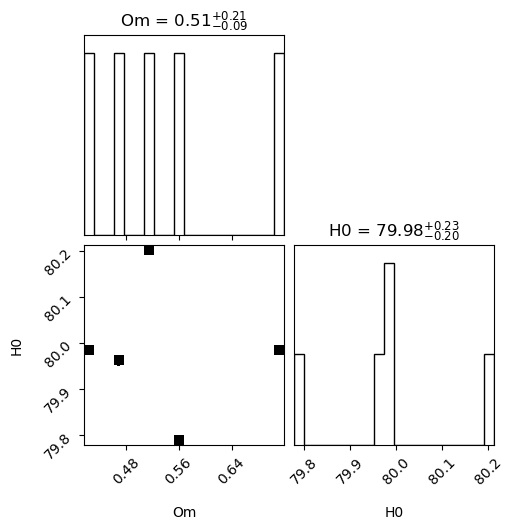

In [ ]:
fig = corner.corner(
    flat_samples, labels=["Om","H0"], levels=[0.68,0.95], show_titles=True, truths=[0.27,71]
);